shape (1797, 64)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_3004\4205054562.py:61: RuntimeWarning: divide by zero encountered in log
  H = -np.sum(Pi*np.log(Pi))
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_3004\4205054562.py:61: RuntimeWarning: invalid value encountered in multiply
  H = -np.sum(Pi*np.log(Pi))
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_3004\4205054562.py:59: RuntimeWarning: invalid value encountered in divide
  Pi /= Z


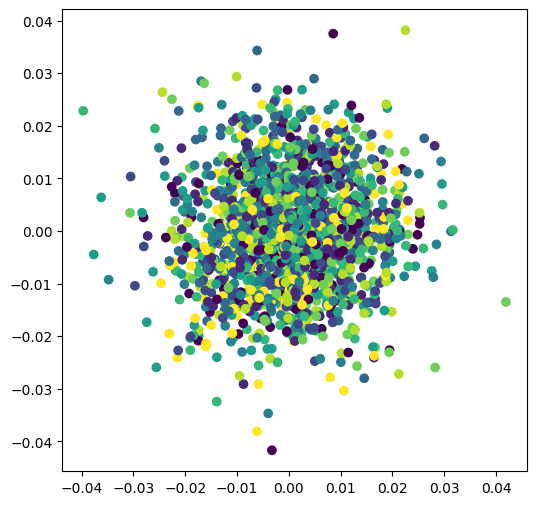

In [15]:
# corteria de gpt  , customizado a mi estilo

import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt


#=======================================================
class T_SNE:
    #-----------------------------------------------------------
    def __init__(self):
        return
    #-----------------------------------------------------------
    def distancias_(self,X):
        m,n = X.shape
        D = np.zeros((m,m))
        for i in range(m):
            for j in range(m):
                D[i,j] = np.sum((X[i]-X[j])**2)
        return D
    #-----------------------------------------------------------
    def distancias(self,X):  #||x||² + ||x||² − 2x·x
        m , n = X.shape
        sum_X = np.sum(X**2,axis=1)
        A = sum_X.reshape(m,1) 
        B = sum_X.reshape(1,m)
        D = A + B -2 *X@X.T
        return D
     #-------------------------------------------------------------
    def similitudes_espacio_original(self,D, sigma=1.0):
        m = D.shape[0]
        P = np.zeros((m,m))
        for i in range(m):
            z = 0
            for j in range(m):
                if i != j:
                    P[i,j] = np.exp(-D[i,j]/(2*sigma**2))
                    z += P[i,j]
            for j in range(m):
                if i!=j:
                    P[i,j]/=z
        P = (P + P.T) / (2*m)                                   # simetrizando (p(j|i) + p(i|j)) / 2N
        return P
    #-----------------------------------------------------------
    def similitudes_con_perplejidad(self,D,per=30,tol=1e-5,max_iter=50): 
        m = D.shape[0]
        P = np.zeros((m,m))
        logU = np.log(per)                   #Perplexity(Pi)=2^H(Pi),   H(Pi)=−j∑Pj∣i log2Pj∣i
        for i in range(m):
            beta = 1.0                               # beta = 1/(2*sigma^2)
            betamin = -np.inf
            betamax = np.inf
            Di = np.delete(D[i], i)  
            for _ in range(max_iter):
                # Numerador
                Pi = np.exp(-Di * beta)
                Z = Pi.sum()
                Pi /= Z
                # Entropía
                H = -np.sum(Pi*np.log(Pi))
                Hdiff = H - logU
                if abs(Hdiff) < tol:
                    break
                if Hdiff > 0:
                    betamin = beta
                    beta = beta*2 if betamax==np.inf else (beta+betamax)/2
                else:
                    betamax = beta
                    beta = beta/2 if betamin==-np.inf else (beta+betamax)/2
            # Poner en la matriz final
            idx = [j for j in range(m) if j != i]
            P[i, idx] = Pi
        return (P + P.T)/(2*m)
    #------------------------------------------------------------
    def probabilidades_espacio_reducido(self,Y):
        m = Y.shape[0]
        Q = np.zeros((m,m))
        for i in range(m):
            for j in range(m):
                if i != j:
                    Q[i,j] = 1 / (1 + np.sum((Y[i]-Y[j])**2))
        Q /= np.sum(Q)
        return Q
    #----------------------------------------------------------------
    def probabilidades_espacio_reducido_(self,Y):
        m,n = Y.shape
        sum_Y = np.sum(Y**2,axis=1)
        A = sum_Y.reshape(m,1)
        B = sum_Y.reshape(1,m)
        D = A + B - 2 * Y @ Y.T
        Q = 1 /(1 + D)
        np.fill_diagonal(Q,0)                # diagonal 0's
        Q /=np.sum(Q)
        return Q
    #------------------------------------------------------------
    def gradiente(self,P,Q,Y):
        m = Y.shape[0]
        dY = np.zeros_like(Y)
        for i in range(m):
            for j in range(m):
                if i != j:
                    dY[i] += 4*(P[i,j]-Q[i,j]) * (Y[i]-Y[j]) / (1 + np.sum((Y[i]-Y[j])**2))
        return dY
    #-----------------------------------------------------------------------------------
    def gradiente_(self,P,Q,Y):                   # optimizado, entender luego
        sum_Y = np.sum(Y**2, axis=1)
        D = sum_Y[:,None] + sum_Y[None,:] - 2 * Y @ Y.T
        inv = 1 / (1 + D)
        np.fill_diagonal(inv, 0)
        PQ = (P - Q) * inv
        dY = 4 * (np.diag(np.sum(PQ, axis=1)) - PQ) @ Y
        return dY
    #--------------------------------------------------------------------------------
    def transformar_entrenar(self,X,N=500,lr =0.1,momentum=0.8):
        D = self.distancias(X)
        P = self.similitudes_con_perplejidad(D)
        m,n = X.shape
        Y = np.random.randn(m,2)*0.01
        Y_previo = Y.copy()
        for _ in range(N):
            Q = self.probabilidades_espacio_reducido_(Y)
            dy = self.gradiente_(P,Q,Y)                              # en lugar de movernos en direccion de gradiente,agregamos un empuje en la iteracion anterior
            Y_nuevo = Y - lr * dy + momentum*(Y - Y_previo )        #(t+1)=Y(t)−lr⋅∇C+momentum⋅(Y(t)−Y(t−1))
            Y_previo , Y = Y, Y_nuevo
        return Y
    #----------------------------------------------------------------------------------
    def graficar(self,Y,y):
        plt.figure(figsize=(6,6)) 
        plt.scatter(Y[:,0],Y[:,1],c = y)
        plt.show()
    #-----------------------------------------------------------------------
#==============================================================================================
if __name__=='__main__':
    data = load_digits()
    X, y = data.data, data.target
    print(f"shape {X.shape}")
    t_sne = T_SNE()
    Y = t_sne.transformar_entrenar(X)
    t_sne.graficar(Y,y)
    